In [40]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [41]:
words = open('names.txt', 'r').read().splitlines()
words[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [42]:
chars = sorted(list(set(''.join(words))))
stoi = {ch : i+1 for i,ch in enumerate(chars)}
stoi['.'] = 0
itos = {i : ch for ch,i in stoi.items()}

In [43]:
block_size = 3
def build_dataset(words):
    X, Y = [],[]
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X,Y

import random
random.seed(42)
random.shuffle(words)

words_size = len(words)
train_size = int(0.8 * words_size)
train_dev_size = int(0.9 * words_size)

Xtr, Ytr = build_dataset(words[:train_size])
Xdev, Ydev = build_dataset(words[train_size:train_dev_size])
Xte, Yte = build_dataset(words[train_dev_size:])

In [44]:
print( Xtr.shape, Ytr.shape)
print(Xdev.shape, Ydev.shape)
print(Xte.shape, Yte.shape)

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


____________________________________________________________________________________________________________________________________________________

In [45]:
vocab_size = len(itos)
n_embd = 50
n_hidden = 400

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((block_size*n_embd, n_hidden), generator=g) * 0.1
b1 = torch.zeros(n_hidden)
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.1
b2 = torch.zeros(vocab_size)

bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters))

72977


In [46]:
for p in parameters:
    p.requires_grad = True

In [47]:
max_steps = 200000
batch_size = 128
stepi = []
lossi = []

for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    emb = C[Xb]
    embcat = emb.view(emb.shape[0],-1)
    hpreact = embcat @ W1
    #______________________________________
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi  + bnbias
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
    #______________________________________
    h = torch.tanh(hpreact)
    logits = h @ W2 +b2
    loss = F.cross_entropy(logits, Yb)

    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1
    if(i >= 100000):
        lr = 0.001
    for p in parameters:
        p.data += -lr * p.grad

    stepi.append(i)
    lossi.append(loss.item())

    if i%10000==0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')

      0/ 200000: 3.7736
  10000/ 200000: 2.0661
  20000/ 200000: 2.0988
  30000/ 200000: 2.1593
  40000/ 200000: 1.9655
  50000/ 200000: 2.0204
  60000/ 200000: 2.0074
  70000/ 200000: 1.8682
  80000/ 200000: 2.0650
  90000/ 200000: 2.0536
 100000/ 200000: 2.1964
 110000/ 200000: 2.0203
 120000/ 200000: 1.9825
 130000/ 200000: 1.8815
 140000/ 200000: 1.9414
 150000/ 200000: 1.9287
 160000/ 200000: 1.9648
 170000/ 200000: 1.9727
 180000/ 200000: 1.9851
 190000/ 200000: 2.0939


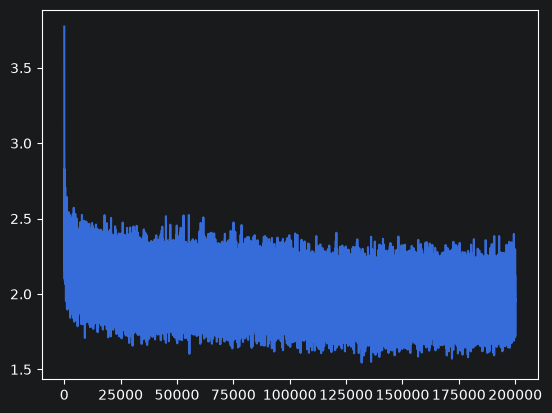

In [48]:
plt.plot(stepi, lossi)

In [49]:
@torch.no_grad()
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1
  hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
  h = torch.tanh(hpreact)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.941576361656189
val 2.0639688968658447


_________________________________________________________________________________________________________________________________________________________